In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# config
SEQ_LEN = 7200
HORIZON = 60
STEP = 20
LSR_MODEL_PATH = "LSR_Residual_Model.keras"
PURE_MODEL_PATH = "Pure_LSTM_Model.keras"

In [2]:
# data stuff
path = kagglehub.dataset_download("rockinbrock/spy-1-minute-data")
files = os.listdir(path)
csv_file = [f for f in files if f.lower().endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# last 100k rows for ram, sort by date
df = df.tail(100_000).reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# split
df_train = df.tail(50_000).reset_index(drop=True)
features = ['open','high','low','close','volume','barCount','average']

print(f"Training Data Shape: {df_train.shape}")

Using Colab cache for faster access to the 'spy-1-minute-data' dataset.
Training Data Shape: (50000, 8)


## 2. Train L+S+R Model (Decomposition)

In [1]:
y_train_raw = df_train['close'].values
N_train = len(df_train)
t_train = np.arange(N_train)

#linear
trend_model = LinearRegression().fit(t_train.reshape(-1, 1), y_train_raw)
L_train = trend_model.predict(t_train.reshape(-1, 1))

#fourier
T_period = 1440
K = 5
seasonal_basis = []
for k in range(1, K+1):
    seasonal_basis.append(np.sin(2*np.pi*k*t_train/T_period))
    seasonal_basis.append(np.cos(2*np.pi*k*t_train/T_period))
seasonal_basis = np.vstack(seasonal_basis).T

seasonal_model = LinearRegression().fit(seasonal_basis, y_train_raw - L_train)
S_train = seasonal_model.predict(seasonal_basis)

R_train_raw = y_train_raw - L_train - S_train

#lstm on residuals
X_all = df_train[features].values.astype(np.float32)
X_lsr, y_lsr = [], []

for i in range(0, N_train - SEQ_LEN - HORIZON, STEP):
    X_lsr.append(X_all[i:i+SEQ_LEN])
    y_lsr.append(R_train_raw[i+SEQ_LEN:i+SEQ_LEN+HORIZON])

X_lsr = np.array(X_lsr, dtype=np.float32)
y_lsr = np.array(y_lsr, dtype=np.float32)

# train that
model_lsr = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 7)),
    Dropout(0.2),
    LSTM(64),
    Dense(128, activation='relu'),
    Dense(HORIZON)
])
model_lsr.compile(optimizer=Adam(1e-3), loss='mse')
model_lsr.fit(X_lsr, y_lsr, epochs=2, batch_size=32, verbose=1)
model_lsr.save(LSR_MODEL_PATH)
print("L+S+R Model Trained.")

NameError: name 'df_train' is not defined

## 3. Train Pure LSTM (Raw Prices)

In [4]:
# scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(df_train[features].values)
y_train_scaled = scaler_y.fit_transform(df_train[['close']].values)

# windows
X_pure, y_pure = [], []
for i in range(0, N_train - SEQ_LEN - HORIZON, STEP):
    X_pure.append(X_train_scaled[i:i+SEQ_LEN])
    # flatten
    y_pure.append(y_train_scaled[i+SEQ_LEN:i+SEQ_LEN+HORIZON].flatten())

X_pure = np.array(X_pure, dtype=np.float32)
y_pure = np.array(y_pure, dtype=np.float32)

# raw lstm
model_pure = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 7)),
    Dropout(0.2),
    LSTM(64),
    Dense(128, activation='relu'),
    Dense(HORIZON)
])
model_pure.compile(optimizer=Adam(1e-3), loss='mse')
model_pure.fit(X_pure, y_pure, epochs=2, batch_size=32, verbose=1)
model_pure.save(PURE_MODEL_PATH)
print("Pure LSTM Model Trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
67/67 ━━━━━━━━━━━━━━━━━━━━ 27s 369ms/step - loss: 0.1292
Epoch 2/2
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 368ms/step - loss: 6.8287e-04
Pure LSTM Model Trained.


## 4. Select Test Window & Run Inference

In [5]:
# test on most volatile window bc fun
WINDOW_DAYS = 30
days = df['date'].dt.date.unique()
candidates = []

for i in range(len(days) - WINDOW_DAYS):
    d_start = days[i]
    d_end   = days[i + WINDOW_DAYS - 1]
    # no training overlap
    if d_end >= df_train['date'].iloc[0].date(): continue

    slice_df = df[(df['date'].dt.date >= d_start) & (df['date'].dt.date <= d_end)]
    if len(slice_df) < 3000: continue

    prices_slice = slice_df['close'].values
    ret = (prices_slice[-1] - prices_slice[0]) / prices_slice[0]
    vol = prices_slice.std() / prices_slice.mean()
    candidates.append((vol / (abs(ret) + 1e-6), i, d_start, d_end))

best_score, idx, w_start, w_end = sorted(candidates, key=lambda x: -x[0])[0]
print(f"Selected Window: {w_start} to {w_end}")

df_test = df[(df['date'].dt.date >= w_start) & (df['date'].dt.date <= w_end)].reset_index(drop=True)
y_test = df_test['close'].values
N_test = len(df_test)
t_test = np.arange(N_test)

#LSR inference
L_test = LinearRegression().fit(t_test.reshape(-1,1), y_test).predict(t_test.reshape(-1,1))

sb_test = []
for k in range(1, K+1):
    sb_test.append(np.sin(2*np.pi*k*t_test/T_period))
    sb_test.append(np.cos(2*np.pi*k*t_test/T_period))
S_test = LinearRegression().fit(np.vstack(sb_test).T, y_test - L_test).predict(np.vstack(sb_test).T)

X_all_test = df_test[features].values.astype(np.float32)
X_seq_test = []
for i in range(0, N_test - SEQ_LEN - HORIZON, STEP):
    X_seq_test.append(X_all_test[i:i+SEQ_LEN])
X_seq_test = np.array(X_seq_test, dtype=np.float32)

R_pred = model_lsr.predict(X_seq_test, verbose=0)

Y_pred_lsr = []
Y_true = []
for idx in range(len(X_seq_test)):
    start = idx*STEP + SEQ_LEN
    end = start + HORIZON
    Y_pred_lsr.append(L_test[start:end] + S_test[start:end] + R_pred[idx])
    Y_true.append(y_test[start:end])
Y_pred_lsr = np.array(Y_pred_lsr)
Y_true = np.array(Y_true)

# raw lstm
X_test_scaled = scaler_X.transform(df_test[features].values)
X_seq_pure = []
for i in range(0, N_test - SEQ_LEN - HORIZON, STEP):
    X_seq_pure.append(X_test_scaled[i:i+SEQ_LEN])
X_seq_pure = np.array(X_seq_pure, dtype=np.float32)

pred_scaled = model_pure.predict(X_seq_pure, verbose=0)
Y_pred_pure = scaler_y.inverse_transform(pred_scaled)

# metrics
mse_lsr = np.mean((Y_pred_lsr - Y_true)**2)
mse_pure = np.mean((Y_pred_pure - Y_true)**2)

print(f"\nL+S+R MSE:   {mse_lsr:.4f}")
print(f"Pure LSTM MSE: {mse_pure:.4f}")

Selected Window: 2020-12-03 to 2021-01-15

L+S+R MSE:   11.5918
Pure LSTM MSE: 2.5068


## 5. Comparative Plotting

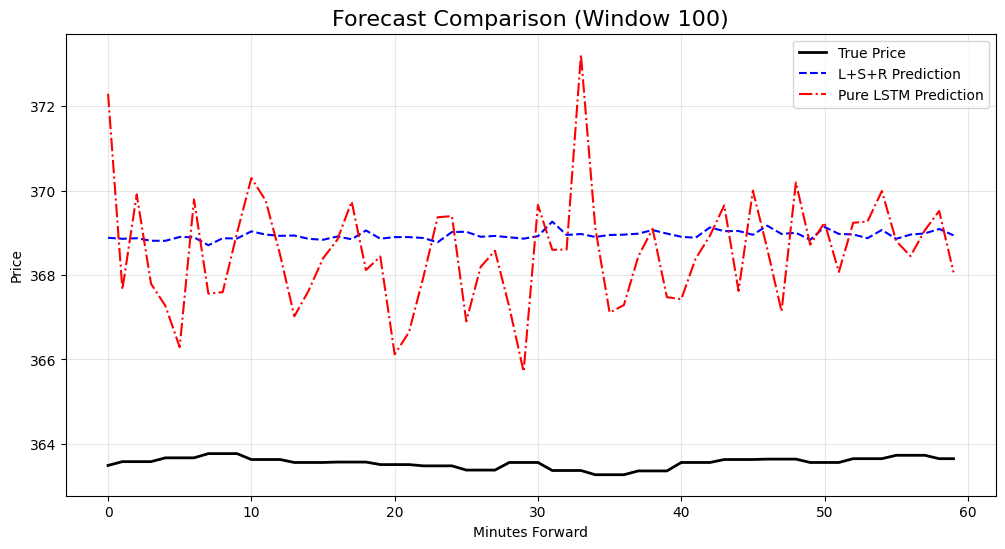

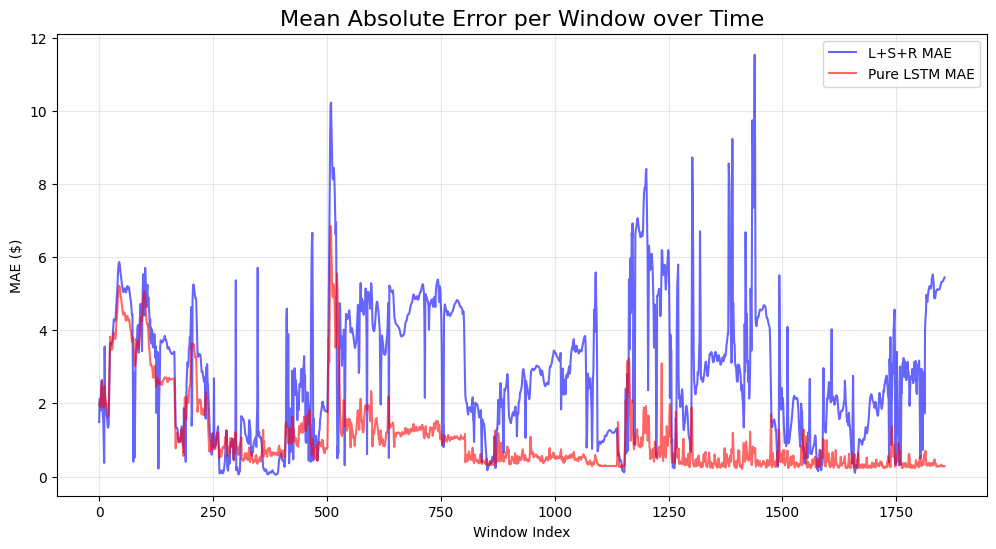

In [6]:
idx = 100  # random sample window

plt.figure(figsize=(12, 6))
plt.plot(Y_true[idx], label="True Price", color='black', linewidth=2)
plt.plot(Y_pred_lsr[idx], label="L+S+R Prediction", color='blue', linestyle="--")
plt.plot(Y_pred_pure[idx], label="Pure LSTM Prediction", color='red', linestyle="-.")

plt.title(f"Forecast Comparison (Window {idx})", fontsize=16)
plt.xlabel("Minutes Forward")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

errors_lsr = np.abs(Y_pred_lsr - Y_true).mean(axis=1)
errors_pure = np.abs(Y_pred_pure - Y_true).mean(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(errors_lsr, label="L+S+R MAE", color='blue', alpha=0.6)
plt.plot(errors_pure, label="Pure LSTM MAE", color='red', alpha=0.6)
plt.title("Mean Absolute Error per Window over Time", fontsize=16)
plt.xlabel("Window Index")
plt.ylabel("MAE ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()